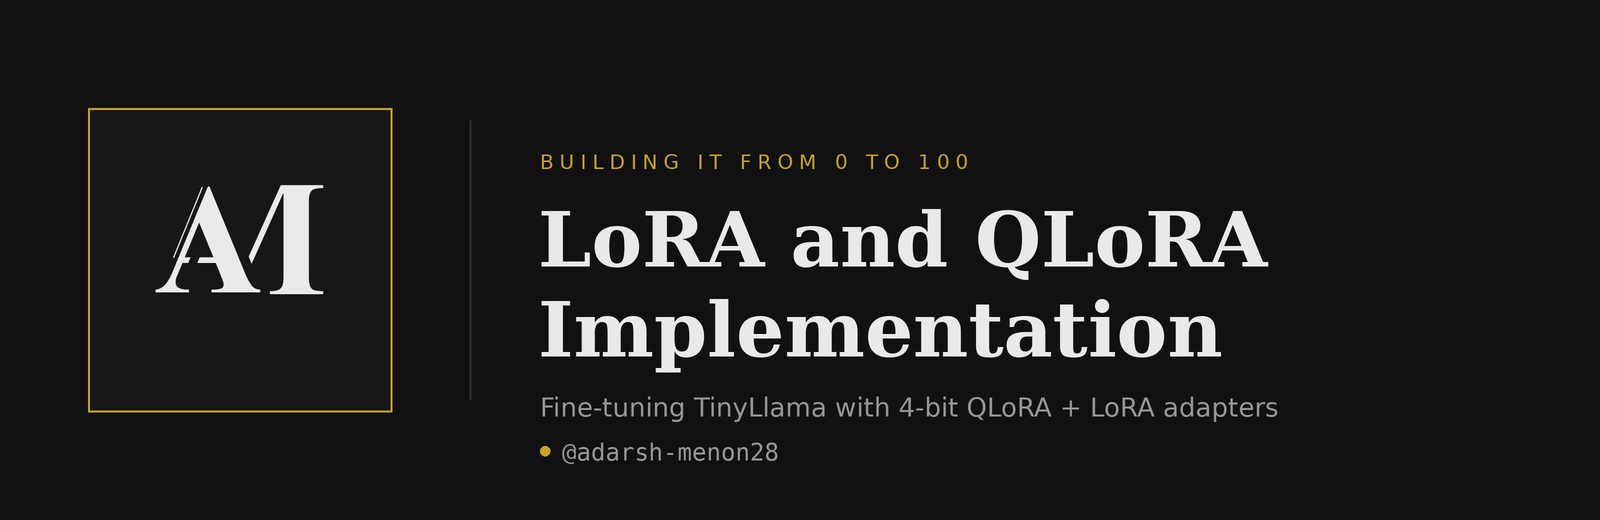

Fine-tuning **TinyLlama-1.1B-Chat** to generate tags for quotes using **QLoRA** (4-bit quantized base model + LoRA adapters).

**Pipeline:** load data → quantize base model (Q) → attach LoRA adapters → train → inference → merge.

---

## 1. Setup

Install the stack and import everything. Key pieces: `BitsAndBytesConfig` (4-bit quantization), `LoraConfig` / `get_peft_model` (the adapters), and `SFTTrainer` (the training loop).

In [1]:
!pip install -U transformers datasets peft accelerate bitsandbytes trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 152.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 37.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.0
    Uninstalling transformers-5.12.0:
      Successfully uninstalled transformers-5.12.0


In [3]:
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments
)
from peft import LoraConfig, get_peft_model, PeftModel
from trl import SFTTrainer

Pick the model. Gemma is left commented out; this run uses TinyLlama and writes to `./TinyLlama`.

In [4]:
#MODEL_NAME = "google/gemma-2-9b-it"
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
OUTPUT_DIR = "./TinyLlama"

## 2. Data preparation

Load the `Abirate/english_quotes` dataset, format each row into a single chat-style training string (user asks for tags → model returns them), slice to 100 examples for a fast run, and sanity-check the output.

In [5]:
dataset = load_dataset("Abirate/english_quotes")

README.md:   0%|          | 0.00/5.55k [00:00<?, ?B/s]

quotes.jsonl:   0%|          | 0.00/647k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2508 [00:00<?, ? examples/s]

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['quote', 'author', 'tags'],
        num_rows: 2508
    })
})

In [10]:
def format_example(example):

  quote = example["quote"].strip()

  tags = ", ".join(example["tags"]) if isinstance(example["tags"], list) else str(example["tags"])

  text = f"""<bos><start_of_turn>user
Generate relevant tags for the following quote.

Quote:
{quote}<end_of_turn>
<start_of_turn>model
{tags}<end_of_turn>"""

  return {"text":text}


In [11]:
small_dataset = dataset["train"].select(range(100))

In [12]:
train_dataset = small_dataset.map(format_example)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [13]:
print(train_dataset['text'][0])

<bos><start_of_turn>user
         Generate relevant tags for the following quote.

         Quote:
         “Be yourself; everyone else is already taken.”<end_of_turn>
         <start_of_turn>model
         be-yourself, gilbert-perreira, honesty, inspirational, misattributed-oscar-wilde, quote-investigator<end_of_turn>


In [14]:
print(train_dataset['text'][1])

<bos><start_of_turn>user
         Generate relevant tags for the following quote.

         Quote:
         “I'm selfish, impatient and a little insecure. I make mistakes, I am out of control and at times hard to handle. But if you can't handle me at my worst, then you sure as hell don't deserve me at my best.”<end_of_turn>
         <start_of_turn>model
         best, life, love, mistakes, out-of-control, truth, worst<end_of_turn>


## 3. Model loading — the "Q" in QLoRA

Load the tokenizer, then load the base model in **4-bit (NF4)** with float16 compute and double quantization. This is what shrinks the model enough to fit on the GPU.

In [15]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

In [17]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

In [18]:
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config = bnb_config,
    device_map="auto",
    dtype=torch.float16,
)

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

## 4. LoRA setup

Define the LoRA adapters (rank 16, alpha 32, dropout 0.05) on the attention projections, wrap the base model with them, and confirm only the adapter weights are trainable.

In [19]:
lora_config = LoraConfig(
    r=16,
    lora_alpha = 32,
    target_modules = ["q_proj","k_proj","v_proj","o_proj"],
    lora_dropout = 0.05,
    bias = "none",
    task_type = "CAUSAL_LM",
)

In [20]:
model = get_peft_model(base_model,lora_config)

In [21]:
model.print_trainable_parameters()

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


## 5. Training

Set training arguments (effective batch size 4 via gradient accumulation, LR 2e-4, 1 epoch), build the `SFTTrainer`, and run the fine-tune.

In [22]:
training_args = TrainingArguments(
    output_dir = OUTPUT_DIR,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps=4,
    learning_rate = 2e-4,
    num_train_epochs=1,
    logging_steps=10,
    save_steps=100,
    save_total_limit=1,
    bf16=True,
    fp16=False,
    report_to = "none",
    remove_unused_columns=False,
)

In [23]:
trainer = SFTTrainer(
    model = model,
    train_dataset = train_dataset,
    args = training_args,
)

/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:964: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  args = SFTConfig(**dict_args)


Adding EOS to train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

In [26]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
10,2.056429
20,1.118473


TrainOutput(global_step=25, training_loss=1.4328937149047851, metrics={'train_runtime': 25.4936, 'train_samples_per_second': 3.923, 'train_steps_per_second': 0.981, 'total_flos': 64454441619456.0, 'train_loss': 1.4328937149047851, 'entropy': 0.8413734495639801, 'mean_token_accuracy': 0.8498812139034271, 'num_tokens': 10339.0, 'epoch': 1.0})

## 6. Save the adapter

Save the trained LoRA adapter and tokenizer to `./TinyLlama/adapter`.

In [27]:
model.save_pretrained(f"{OUTPUT_DIR}/adapter")

In [29]:
tokenizer.save_pretrained(f"{OUTPUT_DIR}/adapter")

('./TinyLlama/adapter/tokenizer_config.json',
 './TinyLlama/adapter/chat_template.jinja',
 './TinyLlama/adapter/tokenizer.json')

## 7. Inference

Reload the adapter on top of the base model, build a test prompt, and generate tags with sampling.

In [30]:
base_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): lora.Linear4bit(
            (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=False)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.05, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=2048, out_features=16, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=16, out_features=2048, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_embedding_B): ParameterDict()
            (lora_magnitude_vector): ModuleDict()
          )
          (k_proj): lora.Linear4bit(
            (base_layer): Linear4bit(in_features=2048, out_features=256, bias=False)
            (lora_dropout): ModuleDict(
        

In [31]:
inference_model = PeftModel.from_pretrained(base_model, f"{OUTPUT_DIR}/adapter")

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [32]:
inference_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [33]:
prompt = """<bos><start_of_turn>user
Generate relevant tags for the following quote.

Quote:
If you want to achieve greatness, stop asking for permission.<end_of_turn>
<start_of_turn>model
"""

In [34]:
input = tokenizer(prompt, return_tensors="pt").to(inference_model.device)

In [36]:
with torch.no_grad():
  output = inference_model.generate(
      **input,
      max_new_tokens=50,
      do_sample=True,
      temperature=0.7,
      top_p=0.9,
  )

[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [37]:
print(tokenizer.decode(output[0], skip_special_tokens=True))

<s> <bos><start_of_turn>user
Generate relevant tags for the following quote.

Quote:
If you want to achieve greatness, stop asking for permission.<end_of_turn>
<start_of_turn>model
art, creativity, inspiration, motivation<end_of_turn></s>


## 8. Merge and save

Fold the LoRA weights into the base model with `merge_and_unload()` and save the full merged model to `./merged_full_model`.

In [39]:
merged_model = inference_model.merge_and_unload()

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:373: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [40]:
tokenizer.save_pretrained("./merged_full_model")

('./merged_full_model/tokenizer_config.json',
 './merged_full_model/chat_template.jinja',
 './merged_full_model/tokenizer.json')

In [41]:
merged_model.save_pretrained("./merged_full_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 9. Push to the Hugging Face Hub

You can publish the lightweight **LoRA adapter** (recommended — a few MB) or the **merged full model**. Authenticate first with a token that has **write** access. In Colab, save it in Secrets (🔑 icon) as `HF_TOKEN`.

In [ ]:
from huggingface_hub import login

# Colab: read the token from Secrets
from google.colab import userdata
login(userdata.get("HF_TOKEN"))

# Or run login() with no args and paste a write token when prompted.

In [ ]:
HF_REPO = "your-username/tinyllama-quote-tagger"   # <-- change to your HF username

### Option A — push the LoRA adapter (recommended)

Uploads only the adapter weights. Add `private=True` if you don't want it public.

In [ ]:
model.push_to_hub(HF_REPO)
tokenizer.push_to_hub(HF_REPO)

### Option B — push the merged full model (optional)

Uploads the full weights. Heavier, and merged on a 4-bit base so generations may drift slightly.

In [ ]:
merged_model.push_to_hub(HF_REPO + "-merged")
tokenizer.push_to_hub(HF_REPO + "-merged")

## 10. Load & run inference from the Hub

Pull the adapter straight from your repo, attach it to a freshly loaded 4-bit base, and generate.

In [ ]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

hub_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.float16,
)
hub_model = PeftModel.from_pretrained(hub_base, HF_REPO)
hub_tokenizer = AutoTokenizer.from_pretrained(HF_REPO)
hub_model.eval()

In [ ]:
prompt = """<bos><start_of_turn>user
Generate relevant tags for the following quote.

Quote:
If you want to achieve greatness, stop asking for permission.<end_of_turn>
<start_of_turn>model
"""

inp = hub_tokenizer(prompt, return_tensors="pt").to(hub_model.device)

with torch.no_grad():
    out = hub_model.generate(
        **inp,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )

print(hub_tokenizer.decode(out[0], skip_special_tokens=True))

**If you pushed the merged model instead (Option B)**, load it directly — no base/adapter step:

In [ ]:
# merged_from_hub = AutoModelForCausalLM.from_pretrained(
#     HF_REPO + "-merged", device_map="auto", dtype=torch.float16
# )
# merged_tok = AutoTokenizer.from_pretrained(HF_REPO + "-merged")